In [1]:
!pip install networkx matplotlib


In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from datetime import datetime

# Create a directed graph
G = nx.DiGraph()

# Add nodes (users, devices, IPs, apps, CVEs, etc.)
G.add_node("user1", type="User", name="Alice")
G.add_node("device1", type="Device", os="Windows")
G.add_node("ip1", type="IP", address="192.168.1.1")
G.add_node("app1", type="App", name="WebApp")
G.add_node("cve1", type="CVE", id="CVE-2021-12345", description="Sample CVE")

# Add edges (relationships between nodes)
# user-logged-in→device (with weight and timestamp)
G.add_edge("user1", "device1", relationship="user-logged-in", weight=5, timestamp=datetime(2023, 8, 29))

# device-connected-to→ip (with timestamp)
G.add_edge("device1", "ip1", relationship="device-connected-to", timestamp=datetime(2023, 8, 29))

# user-accessed→app (with timestamp)
G.add_edge("user1", "app1", relationship="user-accessed", timestamp=datetime(2023, 8, 29))

# device-lateral-auth→device (RDP) (with timestamp)
G.add_edge("device1", "device1", relationship="device-lateral-auth", protocol="RDP", timestamp=datetime(2023, 8, 29))

# user-member-of→group (with timestamp)
G.add_node("group1", type="Group", name="Admins")
G.add_edge("user1", "group1", relationship="user-member-of", timestamp=datetime(2023, 8, 29))

# device-has-vuln→CVE (with timestamp)
G.add_edge("device1", "cve1", relationship="device-has-vuln", timestamp=datetime(2023, 8, 29))

# Visualize the Graph
# Prepare node labels and edge labels
node_labels = {node: f"{data['type']} - {data.get('name', '')}" for node, data in G.nodes(data=True)}
edge_labels = {(u, v): f"{data['relationship']}" for u, v, data in G.edges(data=True)}




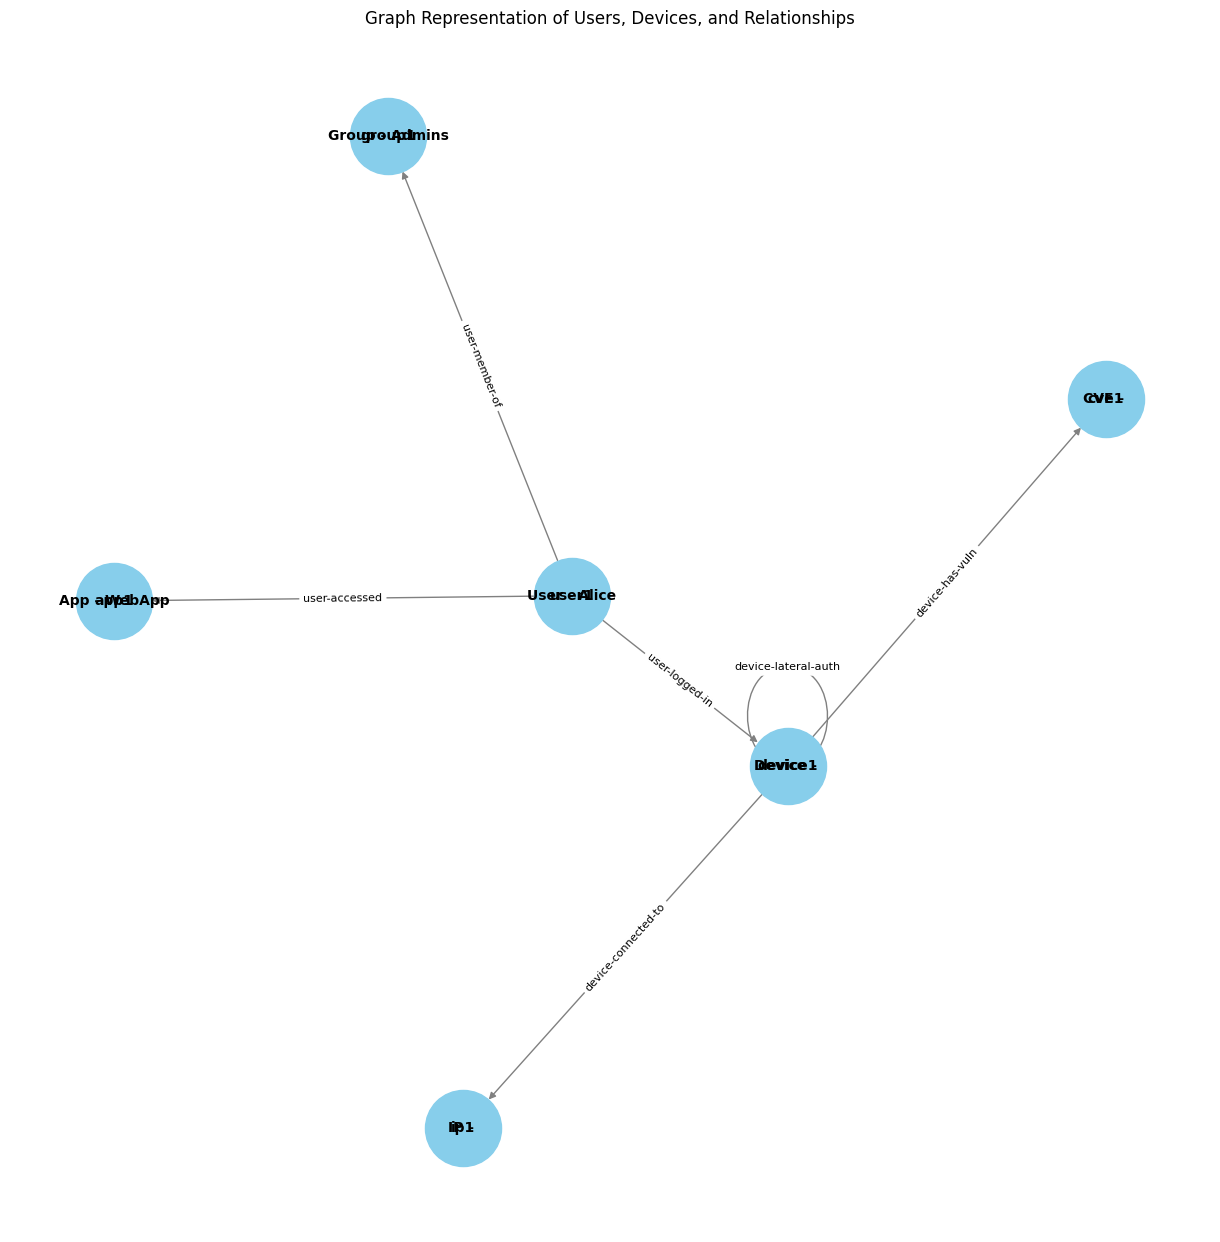

In [4]:
# Plot the graph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)  # Layout the graph
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title("Graph Representation of Users, Devices, and Relationships")
plt.show()

# Directly Using the Module

In [2]:
%load_ext autoreload
%autoreload 2

from src.political_party_analysis.loader import DataLoader
from src.political_party_analysis.visualization import scatter_plot, plot_density_estimation_results
import pandas as pd
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
import numpy as np

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from matplotlib import pyplot


In [3]:
dataloader_obj = DataLoader()
dataloader_obj.preprocess_data()
dataloader_obj.party_data.head(2)

No duplicate rows found.


,,,eastwest,eu_position,eu_position_sd,eu_salience,eu_dissent,eu_blur,eu_cohesion,eu_foreign,eu_intmark,eu_budgets,eu_asylum,lrgen,lrecon,lrecon_sd,lrecon_salience,lrecon_dissent,lrecon_blur,galtan,galtan_sd,galtan_salience,galtan_dissent,galtan_blur,immigrate_policy,immigrate_salience,immigrate_dissent,multiculturalism,multicult_salience,multicult_dissent,redistribution,redist_salience,environment,enviro_salience,spendvtax,deregulation,econ_interven,civlib_laworder,sociallifestyle,religious_principles,ethnic_minorities,nationalism,urban_rural,protectionism,regions,russian_interference,anti_islam_rhetoric,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership
party_id,party,country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
102,PS,1,0.769385,0.677676,-1.411129,-0.990515,0.128429,-0.680053,0.829405,0.999698,-0.142742,0.347550,1.170374,-1.321254,-1.264026,-1.030492,1.242326,-0.525336,-1.468783,-0.755696,-0.057984,-1.564344,-0.162291,-0.072761,-0.785321,-0.858967,0.498288,-0.909683,-0.580683,0.767777,-1.346992,1.432068,-0.308276,-0.195745,-1.154983,-1.243666,-1.391105,-0.779179,-0.817577,-1.012917,-0.787471,-0.611732,-0.678827,0.527938,0.820575,-1.20645,-0.317593,-0.727529,-0.864042,-1.049322,0.345949
103,SP/SPA,1,0.769385,0.629251,-1.059985,-1.045945,-0.049157,-0.938634,0.623052,0.999698,-0.142742,0.621568,1.092286,-0.897553,-0.864574,-1.211385,1.073358,-0.525336,-1.298559,-0.817673,-0.440121,-1.158335,-0.162291,-0.055594,-0.527463,-0.725034,1.049637,-0.811506,-0.264741,1.000825,-1.141531,1.374027,-0.423995,-0.195745,-0.845015,-1.151550,-1.175799,-0.546940,-0.850274,-0.973872,-0.859009,-0.752165,-0.852606,0.249590,0.437647,-1.20645,-0.273124,-0.630913,-0.899349,-1.162645,-0.035948


In [4]:
df = dataloader_obj.party_data.copy()

In [5]:
pca = PCA(n_components=2, random_state=42)
reduced_dim_data = pd.DataFrame(pca.fit_transform(df),columns=["PC1","PC2"],index=df.index)

In [6]:
reduced_dim_data.head()

,,,PC1,PC2
party_id,party,country,,
102,PS,1,-4.490752,-1.167904
103,SP/SPA,1,-4.276893,-0.620472
104,ECOLO,1,-5.568635,-2.216198
105,AGALEV,1,-5.492630,-2.053194
106,PRL/MR,1,-1.903620,3.587709


In [7]:
origignal = pca.inverse_transform(reduced_dim_data)
origignal.columns = df.columns

In [8]:
origignal.head()

,,,eastwest,eu_position,eu_position_sd,eu_salience,eu_dissent,eu_blur,eu_cohesion,eu_foreign,eu_intmark,eu_budgets,eu_asylum,lrgen,lrecon,lrecon_sd,lrecon_salience,lrecon_dissent,lrecon_blur,galtan,galtan_sd,galtan_salience,galtan_dissent,galtan_blur,immigrate_policy,immigrate_salience,immigrate_dissent,multiculturalism,multicult_salience,multicult_dissent,redistribution,redist_salience,environment,enviro_salience,spendvtax,deregulation,econ_interven,civlib_laworder,sociallifestyle,religious_principles,ethnic_minorities,nationalism,urban_rural,protectionism,regions,russian_interference,anti_islam_rhetoric,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership
party_id,party,country,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
102,PS,1,0.237279,0.461037,-0.178243,-0.014247,0.039552,-0.229536,0.330239,0.473710,0.184998,0.325547,0.813819,-1.122903,-0.893683,-0.517713,0.339448,-0.205481,-0.531459,-1.070940,0.041573,-0.241496,-0.112640,-0.179481,-1.115552,-0.665588,0.175253,-1.119550,-0.512351,0.194642,-0.888772,0.615079,-1.055966,0.856977,-0.922356,-0.800115,-0.745133,-1.098204,-1.049485,-0.958112,-1.075565,-1.054376,-0.691343,-0.125436,-0.396418,-0.274157,-0.871616,-0.009596,-0.317822,0.056167,-0.775016
103,SP/SPA,1,0.196324,0.544394,-0.210556,0.039034,0.034829,-0.246673,0.372872,0.549265,0.304926,0.423667,0.831158,-0.989759,-0.717763,-0.513903,0.352093,-0.158850,-0.495777,-1.008456,0.045469,-0.266480,-0.036236,-0.094770,-1.034503,-0.669987,0.248576,-1.040614,-0.525867,0.263210,-0.715421,0.523383,-0.951433,0.784509,-0.756501,-0.620318,-0.572787,-1.025970,-0.992717,-0.873218,-1.006837,-1.008308,-0.662951,-0.250356,-0.391213,-0.227661,-0.856276,-0.114941,-0.406635,0.029681,-0.723734
104,ECOLO,1,0.340539,0.407249,-0.157313,-0.099806,0.053479,-0.240801,0.318375,0.434205,0.028377,0.226263,0.921561,-1.516829,-1.316431,-0.609427,0.375937,-0.312337,-0.675219,-1.345924,0.042378,-0.242489,-0.250605,-0.341491,-1.426913,-0.768980,0.089792,-1.428274,-0.576121,0.119816,-1.306697,0.860159,-1.394128,1.112105,-1.334140,-1.213417,-1.137692,-1.392927,-1.311987,-1.249396,-1.361062,-1.300980,-0.850204,0.048847,-0.470216,-0.392178,-1.039962,0.153311,-0.231792,0.106829,-0.983482
105,AGALEV,1,0.327886,0.430118,-0.166180,-0.084245,0.051983,-0.245091,0.329783,0.454763,0.062740,0.253845,0.924125,-1.474622,-1.262465,-0.606736,0.378583,-0.298128,-0.663203,-1.324454,0.043385,-0.249027,-0.228009,-0.316271,-1.399900,-0.768228,0.110611,-1.401864,-0.578492,0.139191,-1.253494,0.831573,-1.360458,1.088381,-1.283017,-1.158608,-1.085221,-1.368534,-1.292248,-1.221744,-1.337760,-1.284342,-0.839823,0.012848,-0.467489,-0.377798,-1.032832,0.122659,-0.256687,0.098944,-0.966178
106,PRL/MR,1,-0.145602,1.069685,-0.414271,0.430640,-0.006806,-0.330309,0.624459,1.015299,1.147137,1.081237,0.810648,0.185374,0.728261,-0.392497,0.383054,0.218774,-0.139174,-0.358632,0.066395,-0.405249,0.541989,0.556191,-0.241071,-0.581793,0.752260,-0.261884,-0.531941,0.728675,0.710963,-0.257325,0.002702,0.100467,0.621224,0.837104,0.820290,-0.300036,-0.388514,-0.080171,-0.310595,-0.481346,-0.330679,-1.139779,-0.281547,0.161388,-0.586709,-0.882379,-0.997644,-0.173857,-0.209205


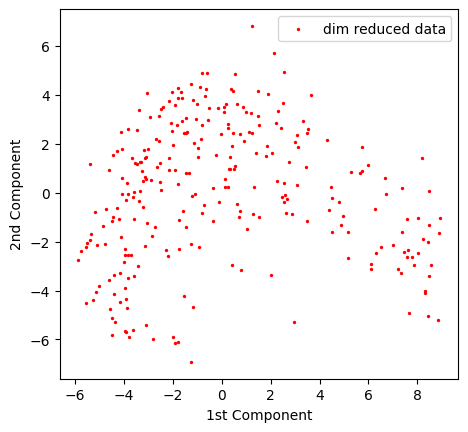

In [9]:
pyplot.figure()
splot = pyplot.subplot()
scatter_plot( reduced_dim_data,color="r",splot=splot,label="dim reduced data")

In [10]:
model = GaussianMixture(4, random_state=42)
model.fit(reduced_dim_data)
samples, sample_shape =model.sample(10)

In [11]:
sampled_data = pd.DataFrame(samples,columns=reduced_dim_data.columns)
predictions = model.predict(sampled_data)

high_dim_sample_data = pca.inverse_transform(sampled_data)
high_dim_sample_data.columns = df.columns

In [12]:
high_dim_sample_data.head()

,eastwest,eu_position,eu_position_sd,eu_salience,eu_dissent,eu_blur,eu_cohesion,eu_foreign,eu_intmark,eu_budgets,eu_asylum,lrgen,lrecon,lrecon_sd,lrecon_salience,lrecon_dissent,lrecon_blur,galtan,galtan_sd,galtan_salience,galtan_dissent,galtan_blur,immigrate_policy,immigrate_salience,immigrate_dissent,multiculturalism,multicult_salience,multicult_dissent,redistribution,redist_salience,environment,enviro_salience,spendvtax,deregulation,econ_interven,civlib_laworder,sociallifestyle,religious_principles,ethnic_minorities,nationalism,urban_rural,protectionism,regions,russian_interference,anti_islam_rhetoric,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership
0,0.428308,-0.656628,0.254650,-0.490112,0.052171,0.104288,-0.314309,-0.582448,-1.053706,-0.822398,0.027018,-1.472523,-1.811157,-0.152796,-0.038185,-0.472931,-0.447164,-0.815021,-0.026120,0.173266,-0.723825,-0.814965,-0.994817,-0.111478,-0.630061,-0.976424,0.006752,-0.582199,-1.786570,0.978063,-1.195836,0.857488,-1.725730,-1.825266,-1.744649,-0.910317,-0.757892,-0.994075,-0.873119,-0.661233,-0.416980,1.112891,-0.137902,-0.487342,-0.338804,0.960420,0.739111,0.254818,-0.645210
1,0.258196,-0.112815,0.043942,-0.207175,0.035104,-0.035718,-0.016410,-0.077850,-0.371422,-0.227726,0.290401,-0.993068,-1.054181,-0.240710,0.100716,-0.265703,-0.366922,-0.703864,0.003485,-0.011353,-0.337398,-0.397951,-0.793380,-0.274397,-0.199913,-0.787161,-0.173019,-0.173506,-1.042348,0.614736,-0.855902,0.647974,-1.028761,-1.027898,-0.975758,-0.752552,-0.672923,-0.739051,-0.729430,-0.634707,-0.409326,0.416287,-0.192942,-0.295216,-0.438918,0.393106,0.196001,0.124445,-0.532235
2,-0.009326,0.015985,-0.006198,0.011198,-0.001114,-0.002859,0.007876,0.014312,0.024516,0.019505,0.001047,0.031432,0.039659,0.002440,0.001570,0.010413,0.009155,0.016477,0.000683,-0.004463,0.016350,0.018301,0.020505,0.001191,0.014791,0.020075,-0.001203,0.013735,0.039105,-0.021145,0.025231,-0.017888,0.037643,0.040173,0.038439,0.018605,0.015213,0.020810,0.017799,0.012989,0.008137,-0.025750,0.002347,0.010602,0.005977,-0.022020,-0.017581,-0.005722,0.013193
3,0.010823,0.134041,-0.051882,0.034601,0.003263,-0.049836,0.084170,0.130725,0.113769,0.121880,0.146577,-0.093302,-0.025735,-0.082952,0.064892,-0.001629,-0.063118,-0.133720,0.009575,-0.057256,0.034372,0.029082,-0.128220,-0.113094,0.079832,-0.130346,-0.094083,0.079740,-0.026704,0.038091,-0.102079,0.091421,-0.037456,-0.007576,-0.003654,-0.131466,-0.134139,-0.099523,-0.130155,-0.142369,-0.094608,-0.107384,-0.061930,-0.013077,-0.133466,-0.074655,-0.114147,-0.009085,-0.092565
4,0.186663,-1.290174,0.499675,-0.526766,0.009773,0.395184,-0.750926,-1.223248,-1.394986,-1.309281,-0.960640,-0.267880,-0.922844,0.460564,-0.455591,-0.274908,0.150499,0.398808,-0.079603,0.486320,-0.666457,-0.686274,0.253507,0.686438,-0.912806,0.278792,0.631163,-0.883272,-0.901526,0.337102,-0.042190,-0.091211,-0.793102,-1.052405,-1.029833,0.326200,0.436114,0.062684,0.339937,0.549375,0.378629,1.388188,0.329451,-0.207312,0.684859,1.077912,1.207415,0.214521,0.227107


/Users/mitesh1.gupta/Documents/New_Learning/Machine_learning/ML_End_to_End/datascientist-politicalparties-python/src/political_party_analysis/visualization.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  splot.legend()


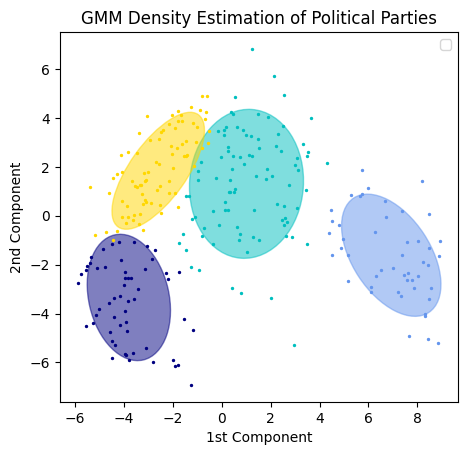

In [13]:
plot_density_estimation_results( X= reduced_dim_data,Y_=model.predict(reduced_dim_data),
    means= model.means_,
    covariances= model.covariances_,
    title="GMM Density Estimation of Political Parties")

In [14]:
lr_cols = ["lrgen", "lrecon"]

# Check which of the columns are available in the preprocessed data
existing_lr_cols = [col for col in lr_cols if col in df.columns]
# Create a composite score. Since data is scaled, a value <= 0 can be
# considered left-of-center and > 0 as right-of-center.
lr_score = df[existing_lr_cols].mean(axis=1)
left_mask = lr_score <= 0
right_mask = lr_score > 0




Text(0.5, 1.0, 'Lefty/righty parties')

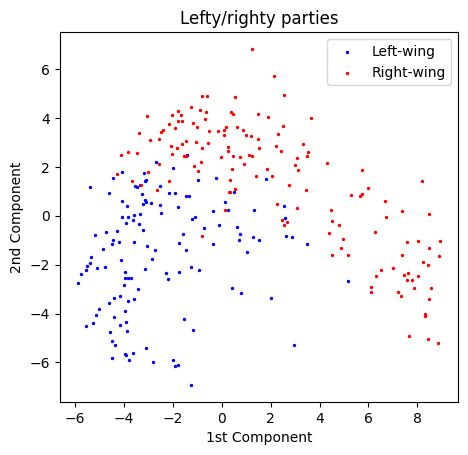

In [15]:
pyplot.figure()
splot = pyplot.subplot()
# Plot left-wing parties in blue
scatter_plot(reduced_dim_data[left_mask], color="blue", splot=splot, label="Left-wing")

# Plot right-wing parties in red
scatter_plot(reduced_dim_data[right_mask], color="red", splot=splot, label="Right-wing")
pyplot.title("Lefty/righty parties")

In [16]:
import matplotlib.pyplot as plt

def plot_finnish_parties(transformed_data: pd.DataFrame, splot: plt.Axes = None):
    """Plots Finnish political parties on a 2D scatter plot with predefined colors."""
    
    finnish_parties = [
        {"parties": ["SDP", "VAS", "VIHR"], "country": 14, "color": "r"},
        {"parties": ["KESK", "KD"], "country": 14, "color": "g"},
        {"parties": ["KOK", "SFP"], "country": 14, "color": "b"},
        {"parties": ["PS"], "country": 14, "color": "k"},
    ]
    if not all(level in transformed_data.index.names for level in ["country", "party"]):
        print("Warning: 'country' and 'party' not in index. Cannot plot Finnish parties.")
        return

    if splot is None:
        fig, splot = plt.subplots(figsize=(8, 6))

    for party_group in finnish_parties:
        # Filter data for the specific country and parties
        mask = (transformed_data.index.get_level_values("country") == party_group["country"]) & \
               (transformed_data.index.get_level_values("party").isin(party_group["parties"]))
        party_data = transformed_data[mask]
        if not party_data.empty:
            scatter_plot(party_data,color=party_group["color"],
                        splot=splot,size=25,  # Make points larger to be visible
                        label=f"{', '.join(party_group['parties'])}"
                        )
            # Add text labels for each party for better readability
            for idx, row in party_data.iterrows():
                splot.text(row.iloc[0] + 0.1, row.iloc[1], idx[1], fontsize=9)


Text(0.5, 1.0, 'Finnish Parties in the European Political Landscape')

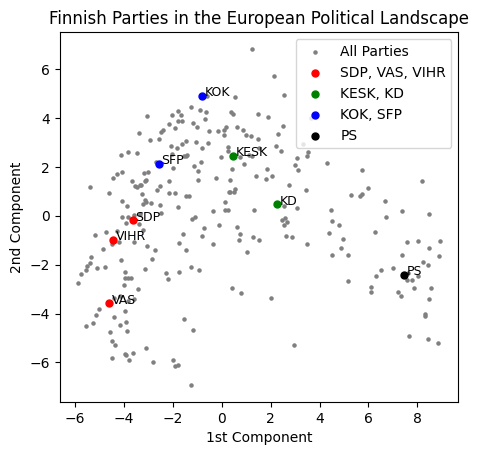

In [16]:
pyplot.figure()
splot = pyplot.subplot()
# First plot all parties as a grey background for context
scatter_plot(reduced_dim_data, color="grey", splot=splot, label="All Parties", size=5)
# Then plot the Finnish parties on top
plot_finnish_parties(reduced_dim_data, splot=splot)
pyplot.title("Finnish Parties in the European Political Landscape")



(array([1., 0., 1., 0., 3., 7., 5., 5., 6., 4.]),
 array([-0.81653247, -0.69340003, -0.57026759, -0.44713515, -0.32400271,
        -0.20087027, -0.07773783,  0.04539461,  0.16852705,  0.29165949,
         0.41479193]),
 <BarContainer object of 10 artists>)

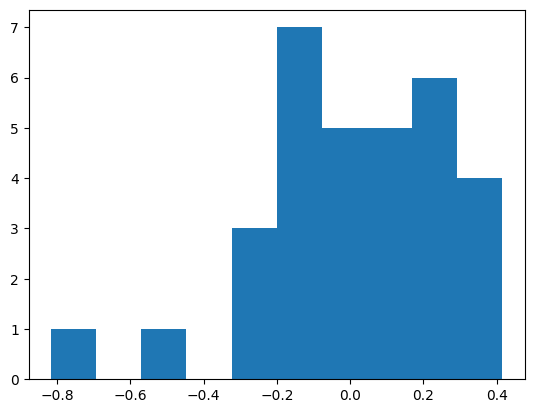

In [18]:
# df.groupby('country')['lrgen'].mean()
plt.hist(df.groupby('country')['lrgen'].mean())




# Import Modules and Libraries

In [1]:
import pandas as pd
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler


### Data Understanding On High Level:

1. COUNTRY = unique identifier for each country.
    Country_ID Country_Abbreviation Country
    1           BE                  Belgium 

2. EASTWEST = 0: party from Central/Eastern Europe, 1: party from EU-15
    PARTY_ID = unique identifier for each party.5
    PARTY = party abbreviation.

##General Questions on European Integration

3. EU_POSITION = overall orientation of the party leadership towards European integration in
2019.
   1=Strongly opposed
   2=Opposed
   3=Somewhat opposed
   4=Neutral
   5=Somewhat in favor
   6=In favor
   7=Strongly in favor

##Specific EU Policy Questions

4. EU_SALIENCE = relative salience of European integration in the party’s public stance in 2019.
    0 = European Integration is of no importance.
    :
    10 = European Integration is of great importance

5. EU_DISSENT = degree of dissent on European integration in 2019.
    0 = Party was completely united.
    :
    10 = Party was extremely divided

##Ideological Questions

6. LRGEN = position of the party in 2019 in terms of its overall ideological stance.
    0 = Extreme left
    :
    5 = Center
    :
    10 = Extreme righ

7. GALTAN = position of the party in 2019 in terms of their views on social and cultural values.
    “Libertarian”/“postmaterialist”  or Traditional/Authoritarian


##POLICY Dimension

8. IMMIGRATE_POLICY = position on immigration policy.
    0 = Strongly favors a liberal policy on immigration
    :
    10 = Strongly favors a restrictive policy on immigratio


9. REDISTRIBUTION = position on redistribution of wealth from the rich to the poor. poor.
    0 = Strongly favors redistribution 
    :
    10 = Strongly opposes redistribution

10. SPENDVTAX = position on improving public services vs. reducing taxes during 2019.
    0 = Strongly favors improving public services
    :
    10 = Strongly favors reducing taxe

11. EU questions for Turkey: Last 3 columns 'eu_econ_require',
       'eu_political_require', 'eu_googov_require'


#### Initial Data Analysis

In [3]:
data = pd.read_csv("data/raw_data/CHES2019V3.csv")

In [4]:
data.shape

(277, 55)

In [5]:
data.head()

,country,eastwest,party,party_id,eu_position,eu_position_sd,eu_salience,eu_dissent,eu_blur,eu_cohesion,eu_foreign,eu_intmark,eu_budgets,eu_asylum,lrgen,lrecon,lrecon_sd,lrecon_salience,lrecon_dissent,lrecon_blur,galtan,galtan_sd,galtan_salience,galtan_dissent,galtan_blur,immigrate_policy,immigrate_salience,immigrate_dissent,multiculturalism,multicult_salience,multicult_dissent,redistribution,redist_salience,environment,enviro_salience,spendvtax,deregulation,econ_interven,civlib_laworder,sociallifestyle,religious_principles,ethnic_minorities,nationalism,urban_rural,protectionism,regions,russian_interference,anti_islam_rhetoric,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership,eu_econ_require,eu_political_require,eu_googov_require
0,1,1.0,PS,102,6.083334,0.288675,4.272728,2.75,2.166667,6.250,5.444445,4.777778,4.250,5.555555,2.083333,2.250000,0.621582,8.166667,2.2,1.142857,2.916667,1.378954,4.000000,2.5,2.750000,3.416667,4.250000,3.400000,3.083333,4.454546,3.5,1.583333,8.166667,4.500000,4.363637,2.000000,2.0,1.545454,3.090909,2.000000,1.5,2.636364,3.454546,3.333333,6.272728,6.000000,0.111111,2.111111,3.363636,2.181818,1.909091,7.500000,NaN,NaN,NaN
1,1,1.0,SP/SPA,103,6.000000,0.426401,4.181818,2.50,1.714286,6.000,5.444445,4.777778,4.625,5.444445,3.083333,3.083333,0.514929,7.916666,2.2,1.428572,2.750000,1.138180,4.583334,2.5,2.777778,4.083334,4.500000,4.181818,3.333333,5.000000,3.8,2.000000,8.083333,4.272728,4.363637,2.666667,2.2,2.000000,3.666667,1.909091,1.6,2.454546,3.083333,3.000000,5.727272,5.333334,0.111111,2.222222,3.545454,2.090909,1.636364,6.818182,NaN,NaN,NaN
2,1,1.0,ECOLO,104,6.583334,0.514929,4.818182,2.50,1.428572,6.000,5.666666,4.777778,4.750,6.000000,2.083333,2.500000,0.904534,6.250000,3.4,2.000000,1.083333,0.792961,6.272728,1.0,1.625000,2.000000,6.000000,2.000000,1.750000,5.909091,2.7,1.916667,7.000000,0.916667,9.363636,2.166667,2.0,2.181818,2.000000,1.000000,1.9,2.000000,1.750000,1.800000,5.818182,6.166666,0.111111,2.888889,5.636363,2.454546,2.363636,3.909091,NaN,NaN,NaN
3,1,1.0,AGALEV,105,6.583334,0.514929,4.818182,2.50,1.285714,5.875,5.666666,4.777778,4.750,6.000000,2.416667,2.666667,0.887625,6.250000,3.0,2.000000,1.166667,0.834847,6.416666,1.0,1.666667,2.250000,5.583334,2.090909,1.916667,5.818182,2.7,2.250000,7.000000,0.833333,9.500000,2.333333,2.2,2.363636,2.083333,0.909091,1.8,2.000000,1.916667,1.900000,5.909091,6.083334,0.111111,2.777778,5.636363,2.363636,2.000000,4.000000,NaN,NaN,NaN
4,1,1.0,PRL/MR,106,6.500000,0.674200,5.090909,2.00,1.714286,5.500,5.777778,6.000000,5.500,5.666666,6.500000,6.916666,0.900337,8.083333,2.4,1.285714,3.181818,0.981650,4.454546,1.5,3.125000,5.583334,4.666666,4.600000,4.916666,4.181818,4.5,5.833334,6.000000,6.272728,3.818182,6.583334,6.9,6.636363,4.727272,2.727273,1.8,4.454546,3.333333,4.444445,2.727273,6.416666,0.111111,2.333333,4.636363,1.727273,1.636364,7.000000,NaN,NaN,NaN


In [6]:
print( data.columns)
print(data.info())

Index(['country', 'eastwest', 'party', 'party_id', 'eu_position',
       'eu_position_sd', 'eu_salience', 'eu_dissent', 'eu_blur', 'eu_cohesion',
       'eu_foreign', 'eu_intmark', 'eu_budgets', 'eu_asylum', 'lrgen',
       'lrecon', 'lrecon_sd', 'lrecon_salience', 'lrecon_dissent',
       'lrecon_blur', 'galtan', 'galtan_sd', 'galtan_salience',
       'galtan_dissent', 'galtan_blur', 'immigrate_policy',
       'immigrate_salience', 'immigrate_dissent', 'multiculturalism',
       'multicult_salience', 'multicult_dissent', 'redistribution',
       'redist_salience', 'environment', 'enviro_salience', 'spendvtax',
       'deregulation', 'econ_interven', 'civlib_laworder', 'sociallifestyle',
       'religious_principles', 'ethnic_minorities', 'nationalism',
       'urban_rural', 'protectionism', 'regions', 'russian_interference',
       'anti_islam_rhetoric', 'people_vs_elite', 'antielite_salience',
       'corrupt_salience', 'members_vs_leadership', 'eu_econ_require',
       'eu_political

In [7]:
data.describe()

,country,eastwest,party_id,eu_position,eu_position_sd,eu_salience,eu_dissent,eu_blur,eu_cohesion,eu_foreign,eu_intmark,eu_budgets,eu_asylum,lrgen,lrecon,lrecon_sd,lrecon_salience,lrecon_dissent,lrecon_blur,galtan,galtan_sd,galtan_salience,galtan_dissent,galtan_blur,immigrate_policy,immigrate_salience,immigrate_dissent,multiculturalism,multicult_salience,multicult_dissent,redistribution,redist_salience,environment,enviro_salience,spendvtax,deregulation,econ_interven,civlib_laworder,sociallifestyle,religious_principles,ethnic_minorities,nationalism,urban_rural,protectionism,regions,russian_interference,anti_islam_rhetoric,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership,eu_econ_require,eu_political_require,eu_googov_require
count,277.000000,247.000000,277.000000,277.000000,277.000000,277.000000,275.000000,276.000000,247.000000,246.000000,247.000000,246.000000,246.000000,277.000000,277.000000,277.000000,277.000000,275.000000,274.000000,277.000000,277.000000,277.000000,269.000000,275.000000,277.000000,277.000000,276.000000,277.000000,276.000000,276.000000,276.000000,277.000000,277.000000,277.000000,276.000000,277.000000,277.000000,276.000000,277.000000,277.000000,276.000000,276.000000,277.000000,276.000000,273.000000,277.000000,271.000000,277.000000,277.000000,277.000000,276.000000,5.000000,5.000000,5.000000
mean,19.415162,0.582996,1951.158845,4.917130,0.842150,5.897261,2.570918,3.356791,5.396399,4.038155,5.094244,3.745937,3.876398,5.201695,4.887001,1.229147,6.328560,2.904161,3.607507,4.948865,1.415489,6.247573,2.752050,2.868952,5.447036,5.853346,2.694123,5.399761,5.458197,2.512053,4.315145,6.110534,5.105459,4.786327,4.484914,4.700223,4.482308,5.023647,4.273099,4.094198,4.638968,5.072801,4.635424,5.238037,4.569700,2.480042,2.922238,4.732744,4.406580,4.434424,6.882306,4.889286,4.063889,4.417857
std,12.446881,0.494065,1242.757271,1.724002,0.392932,1.643058,1.415309,1.755817,1.200286,1.500251,1.426673,1.452658,1.512406,2.364424,2.089968,0.590655,1.482246,1.345526,1.690698,2.694040,0.631213,1.439352,1.532736,1.626832,2.590079,1.869976,1.423109,2.551021,1.732600,1.291944,2.035313,1.438378,1.967568,2.163304,2.158521,2.175110,2.114988,2.488101,2.785322,2.565751,2.550709,2.652860,1.921620,1.966731,1.756845,1.967108,2.528019,1.885266,2.579491,2.410989,1.791828,1.121480,2.552413,2.388843
min,1.000000,0.000000,102.000000,1.000000,0.000000,1.250000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.222222,0.111111,0.000000,2.200000,0.000000,0.000000,0.400000,0.000000,2.500000,0.166667,0.142857,0.000000,2.263158,0.000000,0.636364,1.250000,0.000000,0.111111,1.000000,0.500000,0.625000,0.200000,0.000000,0.000000,0.333333,0.100000,0.166667,0.000000,0.789474,0.857143,0.600000,0.000000,0.000000,0.000000,0.928571,0.200000,0.000000,1.500000,3.000000,1.250000,1.857143
25%,8.000000,0.000000,811.000000,3.785714,0.554700,4.714286,1.500000,1.918651,4.800000,2.876191,4.458042,2.666667,2.800000,3.380952,3.384615,0.788811,5.200000,1.958333,2.333333,2.714286,1.000000,5.187500,1.500000,1.625000,3.333333,4.500000,1.623512,3.142857,4.212121,1.592857,2.811756,5.200000,3.800000,3.000000,2.911184,3.125000,3.000000,3.000000,1.800000,1.800000,2.500000,2.870536,3.133333,3.748377,3.500000,0.800000,1.142857,3.230769,2.181818,2.266667,5.653846,5.000000,1.625000,1.857143
50%,21.000000,1.000000,2102.000000,5.384615,0.740013,5.769231,2.333333,3.250000,5.785714,4.279221,5.454546,3.944444,4.183333,5.285714,4.833334,1.116969,6.400000,2.750000,3.666667,4.875000,1.325987,6.238095,2.500000,2.700000,5.285714,5.500000,2.500000,5.200000,5.142857,2.400000,4.267361,6.000000,5.363637,4.500000,4.256579,4.720000,4.500000,4.738636,3.700000,3.500000,4.306818,4.730303,4.500000,5.275000,4.687500,2.363636,2.111111,4.466667,3.900000,4.461538,6.897619,5.000000,4.555555,5.375000
75%,29.000000,1.000000,2902.000000,6.428571,1.087353,7.142857,3.500000,4.500000,6.250000,5.250000,6.258333,5.000000,5.000000,7.000000,6.600000,1.511858,7.466667,3.690476,4.666666,7.1

In [8]:
data[['party_id','country','eastwest']].nunique()


party_id    277
country      32
eastwest      2
dtype: int64

In [9]:
## Check Duplicates
print(data.duplicated().sum())
n_duplicates = data.duplicated().sum()

if n_duplicates>0:
    data.drop_duplicates(keep="first",inplace=True)
    data = data.reset_index(drop=True)



0


In [16]:
## Check Nulls
Nulls = data.isnull().sum()[data.isnull().sum()>0]
print(Nulls.count())
print(Nulls)


28
eastwest                  30
party                      1
eu_dissent                 2
eu_blur                    1
eu_cohesion               30
eu_foreign                31
eu_intmark                30
eu_budgets                31
eu_asylum                 31
lrecon_dissent             2
lrecon_blur                3
galtan_dissent             8
galtan_blur                2
immigrate_dissent          1
multicult_salience         1
multicult_dissent          1
redistribution             1
spendvtax                  1
civlib_laworder            1
ethnic_minorities          1
nationalism                1
protectionism              1
regions                    4
anti_islam_rhetoric        6
members_vs_leadership      1
eu_econ_require          272
eu_political_require     272
eu_googov_require        272
dtype: int64


#### hanlding NAN values (Delete Row , Col or Impute)


1. Critical NANs: party is missing, without this it is not useful
    - 'eu_econ_require','eu_political_require', 'eu_googov_require' has 272 Nulls like 95%
    - if we have party_id to party mapping we can use it to update party
    - impute this with party_id, so that informoation is not lost

2. Moderate NANs: 10 - 30% data is missing
    - Analyze from which country are these coming from and what are these columns
    - Understand it first and then impute the value either through some business understanding
    - Below analysis shows only (34 Turkey,35 Norway, 36 Switzerland, 45 Iceland) have them as NANs (is there a specific reason?: These are not EU countries)
    - Null Columns are: eastwest, eu_cohesion,	eu_foreign,	eu_intmark,	eu_budgets	eu_asylum. (which actually are EU policies so they don't have any say) We can assume these as Neutral. and take neutral values.
    eastwest: business should suggest where it belongs to or we research on it
    eu_cohesion [1,7],	eu_foreign [1,7],	eu_intmark [1,7],	eu_budgets [1,7]


3. Low NANs: 1-5% data is missing:
    - For all other numeric columns with missing values, impute them with their respective column median.

In [10]:
Null_obj = data.isnull().sum()
# Find columns with 10-30% nulls
moderate_null_cols = Null_obj[(Null_obj > int(data.shape[0] * .10)) & (Null_obj < int(data.shape[0] * .30))].index.tolist()

nulls_by_country_df = pd.DataFrame({
    col: data[data[col].isnull()].reset_index().groupby('country').size()
    for col in moderate_null_cols
}).fillna(0).astype(int)

display(nulls_by_country_df)


,eastwest,eu_cohesion,eu_foreign,eu_intmark,eu_budgets,eu_asylum
country,,,,,,
3,0,0,1,0,1,1
34,5,5,5,5,5,5
35,9,9,9,9,9,9
36,8,8,8,8,8,8
45,8,8,8,8,8,8


In [11]:
party_id_map = {2406 : "NA"}
def handle_NaN_values(df: pd.DataFrame) -> pd.DataFrame:
       """Write a function to handle NaN values in a dataframe"""
       ##### YOUR CODE GOES HERE #####
       ## Critical NANs
       missing_party_mask = df['party'].isnull()
       df.loc[missing_party_mask, 'party'] = df.loc[missing_party_mask, 'party_id'].map(party_id_map)
       
       ## Moderate NANs
       moderate_nan_cols_dict = {'eu_cohesion':4, 'eu_foreign':4,'eu_intmark':4, 'eu_budgets':4, 'eu_asylum':4}
       moderate_nan_cols_dict = {col:val for col, val in moderate_nan_cols_dict.items() if col in df.columns}
       df.fillna(moderate_nan_cols_dict,inplace=True)
       
       ## Low NANs
       medians = df.median(numeric_only=True)
       df = df.fillna(medians)
       return df

In [31]:
data = handle_NaN_values(data)

In [13]:
data.set_index(['country', 'party', 'party_id',], inplace=True)

In [14]:
data.head()

eastwest  eu_position  eu_position_sd  eu_salience  \
country party  party_id                                                       
1       PS     102            1.0     6.083334        0.288675     4.272728   
        SP/SPA 103            1.0     6.000000        0.426401     4.181818   
        ECOLO  104            1.0     6.583334        0.514929     4.818182   
        AGALEV 105            1.0     6.583334        0.514929     4.818182   
        PRL/MR 106            1.0     6.500000        0.674200     5.090909   

                         eu_dissent   eu_blur  eu_cohesion  eu_foreign  \
country party  party_id                                                  
1       PS     102             2.75  2.166667        6.250    5.444445   
        SP/SPA 103             2.50  1.714286        6.000    5.444445   
        ECOLO  104             2.50  1.428572        6.000    5.666666   
        AGALEV 105             2.50  1.285714        5.875    5.666666   
        PRL/MR 106             2.00  1.714286        5.500    5.777778   

                         eu_intmark  eu_budgets  eu_asylum     lrgen  \
country party  party_id                                                
1       PS     102         4.777778       4.250   5.555555  2.083333   
        SP/SPA 103         4.777778       4.625   5.444445  3.083333   
        ECOLO  104         4.777778       4.750   6.000000  2.083333   
        AGALEV 105         4.777778       4.750   6.000000  2.416667   
        PRL/MR 106         6.000000       5.500   5.666666  6.500000   

                           lrecon  lrecon_sd  lrecon_salience  lrecon_dissent  \
country party  party_id                                                         
1       PS     102       2.250000   0.621582         8.166667             2.2   
        SP/SPA 103       3.083333   0.514929         7.916666             2.2   
        ECOLO  104       2.500000   0.904534         6.250000             3.4   
        AGALEV 105       2.666667   0.887625         6.250000             3.0   
        PRL/MR 106       6.916666   0.900337         8.083333             2.4   

                         lrecon_blur    galtan  galtan_sd  galtan_salience  \
country party  party_id                                                      
1       PS     102          1.142857  2.916667   1.378954         4.000000   
        SP/SPA 103          1.428572  2.750000   1.138180         4.583334   
        ECOLO  104          2.000000  1.083333   0.792961         6.272728   
        AGALEV 105          2.000000  1.166667   0.834847         6.416666   
        PRL/MR 106          1.285714  3.181818   0.981650         4.454546   

                         galtan_dissent  galtan_blur  immigrate_policy  \
country party  party_id                                                  
1       PS     102                  2.5     2.750000          3.416667   
        SP/SPA 103                  2.5     2.777778          4.083334   
        ECOLO  104                  1.0     1.625000          2.000000   
        AGALEV 105                  1.0     1.666667          2.250000   
        PRL/MR 106                  1.5     3.125000          5.583334   

                         immigrate_salience  immigrate_dissent  \
country party  party_id                                          
1       PS     102                 4.250000           3.400000   
        SP/SPA 103                 4.500000           4.181818   
        ECOLO  104                 6.000000           2.000000   
        AGALEV 105                 5.583334           2.090909   
        PRL/MR 106                 4.666666           4.600000   

                         multiculturalism  multicult_salience  \
country party  party_id                                         
1       PS     102               3.083333            4.454546   
        SP/SPA 103               3.333333            5.000000   
        ECOLO  104               1.750000            5.909091   
        AGALEV 105       

<h3> Scaling the features </h3>

What columns to scale:
-  All the columns are of float and range either between 1 to 10 or 1 to 7 so we can bring them to a standard scale so as to avoid any confusion.
- eastwest column is already 0 or 1 and it has categorical significance so we will not scale it.

In [23]:
columns_to_be_scaled = [col for col in data.columns if col != 'eastwest']


In [ ]:
scaler = StandardScaler()
data[columns_to_be_scaled] = scaler.fit_transform(data[columns_to_be_scaled])

In [26]:
data.describe()

,eastwest,eu_position,eu_position_sd,eu_salience,eu_dissent,eu_blur,eu_cohesion,eu_foreign,eu_intmark,eu_budgets,eu_asylum,lrgen,lrecon,lrecon_sd,lrecon_salience,lrecon_dissent,lrecon_blur,galtan,galtan_sd,galtan_salience,galtan_dissent,galtan_blur,immigrate_policy,immigrate_salience,immigrate_dissent,multiculturalism,multicult_salience,multicult_dissent,redistribution,redist_salience,environment,enviro_salience,spendvtax,deregulation,econ_interven,civlib_laworder,sociallifestyle,religious_principles,ethnic_minorities,nationalism,urban_rural,protectionism,regions,russian_interference,anti_islam_rhetoric,people_vs_elite,antielite_salience,corrupt_salience,members_vs_leadership,eu_econ_require,eu_political_require,eu_googov_require
count,247.000000,2.770000e+02,2.770000e+02,2.770000e+02,2.750000e+02,2.760000e+02,2.470000e+02,2.460000e+02,2.470000e+02,2.460000e+02,2.460000e+02,2.770000e+02,2.770000e+02,2.770000e+02,2.770000e+02,2.750000e+02,2.740000e+02,2.770000e+02,2.770000e+02,2.770000e+02,2.690000e+02,2.750000e+02,2.770000e+02,2.770000e+02,2.760000e+02,2.770000e+02,2.760000e+02,2.760000e+02,2.760000e+02,2.770000e+02,2.770000e+02,2.770000e+02,2.760000e+02,2.770000e+02,2.770000e+02,2.760000e+02,2.770000e+02,2.770000e+02,2.760000e+02,2.760000e+02,2.770000e+02,2.760000e+02,2.730000e+02,2.770000e+02,2.710000e+02,2.770000e+02,2.770000e+02,2.770000e+02,2.760000e+02,5.000000,5.000000e+00,5.000000e+00
mean,0.582996,-1.346697e-16,1.282568e-17,3.110228e-16,-1.873249e-16,-2.252626e-16,4.602706e-16,-4.910255e-16,3.164360e-16,-1.733031e-16,-1.949660e-16,3.398806e-16,1.090183e-16,6.412841e-17,4.905823e-16,8.558810e-17,-1.037289e-16,8.977977e-17,-1.923852e-16,-6.573162e-16,-1.320711e-17,-6.459479e-17,-6.412841e-17,-1.667339e-16,8.366898e-17,-1.346697e-16,4.633974e-16,4.183449e-17,-3.153677e-16,-1.282568e-16,1.090183e-16,-1.795595e-16,-2.252626e-17,-2.244494e-16,1.603210e-16,6.436076e-16,8.977977e-17,5.130272e-17,2.574430e-17,3.539842e-17,-6.092199e-16,4.746606e-16,1.854438e-16,-1.282568e-16,-1.442061e-16,4.008025e-16,-2.308623e-16,-1.795595e-16,2.767512e-16,0.000000,6.661338e-17,3.330669e-17
std,0.494065,1.001810e+00,1.001810e+00,1.001810e+00,1.001823e+00,1.001817e+00,1.002030e+00,1.002039e+00,1.002030e+00,1.002039e+00,1.002039e+00,1.001810e+00,1.001810e+00,1.001810e+00,1.001810e+00,1.001823e+00,1.001830e+00,1.001810e+00,1.001810e+00,1.001810e+00,1.001864e+00,1.001823e+00,1.001810e+00,1.001810e+00,1.001817e+00,1.001810e+00,1.001817e+00,1.001817e+00,1.001817e+00,1.001810e+00,1.001810e+00,1.001810e+00,1.001817e+00,1.001810e+00,1.001810e+00,1.001817e+00,1.001810e+00,1.001810e+00,1.001817e+00,1.001817e+00,1.001810e+00,1.001817e+00,1.001837e+00,1.001810e+00,1.001850e+00,1.001810e+00,1.001810e+00,1.001810e+00,1.001817e+00,1.118034,1.118034e+00,1.118034e+00
min,0.000000,-2.276227e+00,-2.147128e+00,-2.833541e+00,-1.819818e+00,-1.915284e+00,-3.670230e+00,-2.029227e+00,-2.875611e+00,-1.894138e+00,-1.905746e+00,-2.109810e+00,-2.289285e+00,-2.084755e+00,-2.790382e+00,-2.162319e+00,-2.137642e+00,-1.691548e+00,-2.246548e+00,-2.608365e+00,-1.689921e+00,-1.678763e+00,-2.106845e+00,-1.923387e+00,-1.896563e+00,-1.870631e+00,-2.433246e+00,-1.947929e+00,-2.069299e+00,-3.559416e+00,-2.344923e+00,-1.927079e+00,-1.988721e+00,-2.164824e+00,-2.123143e+00,-1.888522e+00,-1.500959e+00,-1.533524e+00,-1.822001e+00,-1.617540e+00,-1.969755e+00,-2.362530e+00,-2.605859e+00,-1.263037e+00,-1.158079e+00,-2.021496e+00,-1.633730e+00,-1.842584e+00,-3.009264e+00,-1.883481,-1.232568e+00,-1.198474e+00
25%,0.000000,-6.574607e-01,-7.328769e-01,-7.212872e-01,-7.580465e-01,-8.205596e-01,-4.978892e-01,-7.760923e-01,-4.468396e-01,-7.444772e-01,-7.131633e-01,-7.714511e-01,-7.201568e-01,-7.468545e-01,-7.627634e-01,-7.042246e-01,-7.550165e-01,-8.309541e-01,-6.594299e-01,-7.378263e-01,-8.183955e-01,-7.660411e-01,-8.175536e-01,-7.250338e-01,-7.536708e-01,-8.863076e-01,-7.205007e-01,-7.127751e-01,-7.399941e-01,-6.341745e-01,-6.646894e-01,-8.272347e-01,-7.304021e-01,-7.255144e-01,-7.021276e-01,-8.

In [1]:
import numpy as np

In [4]:
indices = np.arange(15)
indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [ ]:
np.random.shuffle(indices)

None


In [6]:
indices

array([12,  9,  3,  2,  4,  7, 10,  1, 13,  0, 14,  8,  6,  5, 11])

In [9]:
np.maximum(0,4.5)

np.float64(4.5)

In [11]:
np.where(-4.5>0, 1,0)

array(0)

In [1]:
import numpy as np

In [19]:
np.random.rand(3,2)

array([[0.23598303, 0.50590407],
       [0.91308524, 0.52724791],
       [0.84967067, 0.34051253]])

In [26]:
np.random.randn(3,2)

array([[-0.26159907,  0.84776863],
       [-0.28690764, -1.76032889],
       [ 0.57015075,  0.03928515]])